**Libraries**

In [335]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

**Original Dataset**

In [336]:
data = pd.read_stata('/workspaces/malnutrition/NPKR82FL.DTA')
data.head()

,caseid,bidx,v000,v001,v002,v003,v004,v005,v006,v007,...,s604c,s607ea,s607eb,s607ec,s607ed,s607ex,s607f,s607g,s615f,s631o
0,1 1 2,1,NP8,1,1,2,1,916093,magh,2078,...,no,no,no,no,no,no,no,no,NaN,NaN
1,1 8 2,1,NP8,1,8,2,1,916093,magh,2078,...,no,no,yes,no,no,no,NaN,no,NaN,no
2,1 8 2,2,NP8,1,8,2,1,916093,magh,2078,...,NaN,no,yes,no,no,no,NaN,no,NaN,no
3,1 9 3,1,NP8,1,9,3,1,916093,magh,2078,...,no,no,no,no,no,no,yes,no,NaN,no
4,1 19 1,1,NP8,1,19,1,1,916093,magh,2078,...,no,yes,yes,no,no,no,NaN,no,NaN,NaN


In [337]:
data.shape

(5372, 1422)

**Selected Features**

In [338]:
df1 = data.copy()
df1 = df1[['b19', 'v106', 'v525', 'v228', 'v190', 'v102', 'v101', 'v445', 'b11', 'v137', 'v208', 'v130', 'v131', 'm19', 'b4', 'm4', 'v012', 'v212', 'v729', 'v714', 'v481',  'hw71', 'hw70', 'hw72']]
df1.rename(columns={'b19': 'Child_age', 'v106':'Mother_education', 'v525': 'Age_first_sex', 'v228': 'Pregnancy_terminated', 'v190':'Wealth_index', 'v102':'Place_residence', 'v101':'Region', 'v445':'BMI', 'b11':'Birth_interval', 'v137':'Children_under5', 'v208': 'Total_children_ever_born', 'v130':'Religion', 'v131':'Ethnicity', 'm19':'Birth_weight', 'b4':'Child_sex', 'm4':'Breastfeeding_duration', 'v012':'Mother_age_current', 'v212': 'Mother_age_at_first_birth', 'v729':'Father_education', 'v714':'Mother_working', 'v481':'Health_insurance',  'hw71':'Underweight', 'hw70':'Stunting',  'hw72':'Wasting'}, inplace=True)
df1.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,Region,BMI,Birth_interval,Children_under5,...,Child_sex,Breastfeeding_duration,Mother_age_current,Mother_age_at_first_birth,Father_education,Mother_working,Health_insurance,Underweight,Stunting,Wasting
0,41,basic,14.0,no,poorest,rural,koshi,NaN,36.0,1,...,female,NaN,29,17,complete primary,yes,no,NaN,NaN,NaN
1,28,basic,29.0,no,poorest,rural,koshi,NaN,13.0,2,...,female,still breastfeeding,33,30,incomplete primary,no,no,NaN,NaN,NaN
2,42,basic,29.0,no,poorest,rural,koshi,NaN,NaN,2,...,female,NaN,33,30,incomplete primary,no,no,NaN,NaN,NaN
3,17,basic,14.0,no,poorest,rural,koshi,2200.0,207.0,1,...,female,still breastfeeding,34,16,incomplete secondary,no,no,-65.0,-111.0,-19.0
4,40,secondary,17.0,yes,poorer,rural,koshi,2510.0,19.0,2,...,male,NaN,26,21,complete primary,yes,no,-185.0,-311.0,-7.0


*24 features are selected out of 1422 features on the basis of existing litreture, which are:*

'Child_age', 'Mother_education', 'Age_first_sex', 'Pregnancy_terminated', 'Wealth_index', 'Place_residence', 'Region', 'BMI', 'Birth_interval', 'Children_under5', 'Total_children_ever_born','Religion', 'Ethnicity', 'Birth_weight', 'Child_sex', 'Breastfeeding_duration', 'Mother_age_current', 'Mother_age_at_first_birth', 'Father_education', 'Mother_working', 'Health_insurance', 'Underweight', 'Stunting', 'Wasting'

In [339]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5372 entries, 0 to 5371
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Child_age                  5372 non-null   int8    
 1   Mother_education           5372 non-null   category
 2   Age_first_sex              5371 non-null   category
 3   Pregnancy_terminated       5372 non-null   category
 4   Wealth_index               5372 non-null   category
 5   Place_residence            5372 non-null   category
 6   Region                     5372 non-null   category
 7   BMI                        2736 non-null   category
 8   Birth_interval             3172 non-null   float64 
 9   Children_under5            5372 non-null   int8    
 10  Total_children_ever_born   5372 non-null   category
 11  Religion                   5372 non-null   category
 12  Ethnicity                  5372 non-null   category
 13  Birth_weight               3177 n

In [340]:
df2 = df1.copy()
df2.drop(index = 3251, inplace=True) # BMI 9998.0
df2.drop(index = [658,730, 4417], inplace = True) # Religion 96
df2.drop(index = [1369, 602, 603], inplace=True) # Ethnicity 96
df2 = df2[~df2['Birth_weight'].isin(['not weighed at birth', "don't know"])] # Birth_weight 9998 or 9996
df2 = df2[~df2['Wasting'].isin(['height out of plausible limits', 'flagged cases'])] # Wasting 9998 or 9996
df2.drop(index = 1651, inplace=True) # Status 9998

In [341]:
df2.shape

(4704, 24)

In [342]:
# df2 = df2.dropna(subset=['Underweight', 'Stunting', 'Wasting'])

In [343]:
# df2.isnull().sum()

In [344]:
df2.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,Region,BMI,Birth_interval,Children_under5,...,Child_sex,Breastfeeding_duration,Mother_age_current,Mother_age_at_first_birth,Father_education,Mother_working,Health_insurance,Underweight,Stunting,Wasting
0,41,basic,14.0,no,poorest,rural,koshi,NaN,36.0,1,...,female,NaN,29,17,complete primary,yes,no,NaN,NaN,NaN
2,42,basic,29.0,no,poorest,rural,koshi,NaN,NaN,2,...,female,NaN,33,30,incomplete primary,no,no,NaN,NaN,NaN
3,17,basic,14.0,no,poorest,rural,koshi,2200.0,207.0,1,...,female,still breastfeeding,34,16,incomplete secondary,no,no,-65.0,-111.0,-19.0
4,40,secondary,17.0,yes,poorer,rural,koshi,2510.0,19.0,2,...,male,NaN,26,21,complete primary,yes,no,-185.0,-311.0,-7.0
5,59,secondary,17.0,yes,poorer,rural,koshi,2510.0,NaN,2,...,female,NaN,26,21,complete primary,yes,no,-140.0,-243.0,21.0


**Numeric Features**

In [345]:
numeric_cols = ['Child_age', 'Age_first_sex', 'BMI', 'Birth_interval', 'Birth_weight', 'Mother_age_current', 'Mother_age_at_first_birth', 'Children_under5', 'Total_children_ever_born', 'Underweight', 'Stunting', 'Wasting']
df2[numeric_cols] = df2[numeric_cols].apply(pd.to_numeric, errors = 'coerce')

**WHO reference standard**

In [346]:
df2['BMI'] = df2['BMI']/100
df2["Underweight"] = df2["Underweight"]/100
df2['Stunting'] = df2["Stunting"]/100
df2['Wasting'] = df2["Wasting"]/100

df2['Underweight'] = [0 if -2 <= val <= 2 else 1 for val in df2['Underweight']] # Weight-for-Age (WAZ) → Underweight
df2['Stunting'] = [0 if -2 <= val <= 2 else 1 for val in df2['Stunting']] # Height-for-Age (HAZ) → Stunting
df2['Wasting'] = [0 if -2 <= val <= 2 else 1 for val in df2['Wasting']] # Weight-for-Height (WHZ) → Wasting

**Z-score Concept (Standard Deviation Score)**

Malnutrition classification is based on how far a child’s anthropometric measurement deviates from the WHO reference standard for children of the same age and sex. This deviation is quantified using the *Z-score*, also known as the *standard deviation score*.

A Z-score tells you how many standard deviations (SDs) a measurement is from the reference population median.

$$Z = \frac{(X - \mu)}{\sigma}$$

Where,
- $X$ = Observed measurement (e.g. child’s weight or height)
- $\mu$ = Median of the reference population (matched by age and sex)
- $\sigma$ = Standard deviation of the reference population

In [347]:
df2.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,Region,BMI,Birth_interval,Children_under5,...,Child_sex,Breastfeeding_duration,Mother_age_current,Mother_age_at_first_birth,Father_education,Mother_working,Health_insurance,Underweight,Stunting,Wasting
0,41,basic,14.0,no,poorest,rural,koshi,NaN,36.0,1,...,female,NaN,29,17,complete primary,yes,no,1,1,1
2,42,basic,29.0,no,poorest,rural,koshi,NaN,NaN,2,...,female,NaN,33,30,incomplete primary,no,no,1,1,1
3,17,basic,14.0,no,poorest,rural,koshi,22.0,207.0,1,...,female,still breastfeeding,34,16,incomplete secondary,no,no,0,0,0
4,40,secondary,17.0,yes,poorer,rural,koshi,25.1,19.0,2,...,male,NaN,26,21,complete primary,yes,no,0,1,0
5,59,secondary,17.0,yes,poorer,rural,koshi,25.1,NaN,2,...,female,NaN,26,21,complete primary,yes,no,0,1,0


In [348]:
df2.isna().sum()

Child_age                       0
Mother_education                0
Age_first_sex                   1
Pregnancy_terminated            0
Wealth_index                    0
Place_residence                 0
Region                          0
BMI                          2313
Birth_interval               2046
Children_under5                 0
Total_children_ever_born        0
Religion                        0
Ethnicity                       0
Birth_weight                 2190
Child_sex                       0
Breastfeeding_duration       2190
Mother_age_current              0
Mother_age_at_first_birth       0
Father_education               46
Mother_working                  0
Health_insurance                0
Underweight                     0
Stunting                        0
Wasting                         0
dtype: int64

In [349]:
df1['Breastfeeding_duration'].value_counts()

Breastfeeding_duration
still breastfeeding                            2710
ever breastfed, not currently breastfeeding     421
never breastfed                                  46
Name: count, dtype: int64

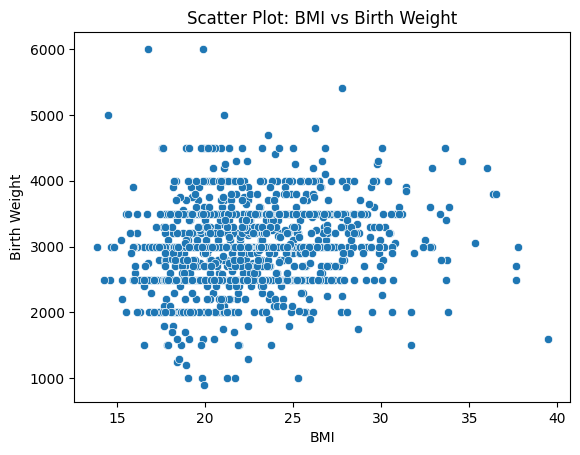

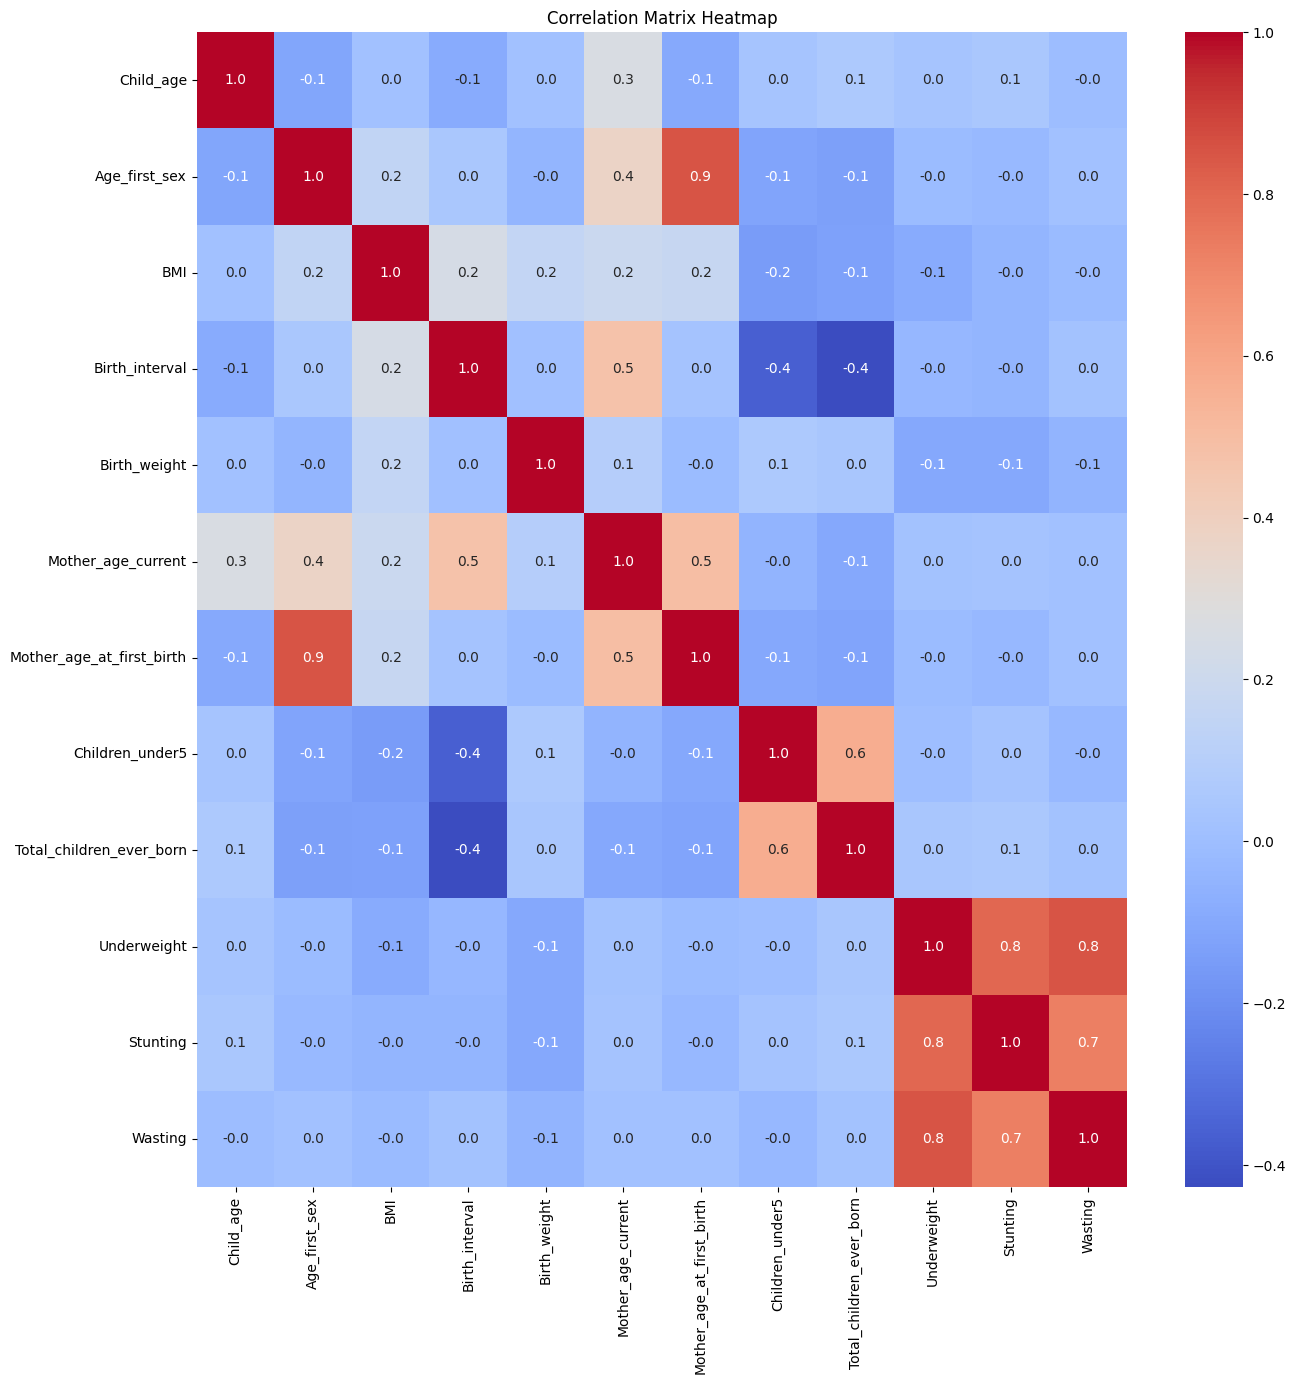

In [350]:
# Create a heatmap
correlation_matrix = df2[numeric_cols].corr()

plt.figure(figsize=(15, 15))  # Set figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.1f')
plt.title("Correlation Matrix Heatmap")
plt.show()

In [351]:
contingency_tabel = pd.crosstab(df2['Mother_education'], df2['Underweight'])
contingency_tabel

Underweight,0,1
Mother_education,,
no education,317,606
basic,649,986
secondary,812,1163
higher,78,93


In [352]:
from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(contingency_tabel)
print("Degrees of Freedom:", dof)
print("Chi-Square Statistic:", chi2)
print("p-value:", p_value)

Degrees of Freedom: 3
Chi-Square Statistic: 15.121014814299773
p-value: 0.0017160999251224728


In [353]:
import numpy as np
def cramers_v(confusion_matrix):
    """Calculate Cramér's V for a contingency table."""
    chi2, p, dof, expected = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum()  # total number of observations
    # number of rows and columns
    r, k = confusion_matrix.shape
    # Cramér's V formula
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

v = cramers_v(contingency_tabel)
print("Cramér's V:", v)

Cramér's V: Underweight
0    0.090261
1    0.072865
dtype: float64


In [354]:
df3 = df2.drop(columns= ['Birth_weight', 'Birth_interval', 'Breastfeeding_duration'])
df3.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,Region,BMI,Children_under5,Total_children_ever_born,...,Ethnicity,Child_sex,Mother_age_current,Mother_age_at_first_birth,Father_education,Mother_working,Health_insurance,Underweight,Stunting,Wasting
0,41,basic,14.0,no,poorest,rural,koshi,NaN,1,1,...,hill janajati,female,29,17,complete primary,yes,no,1,1,1
2,42,basic,29.0,no,poorest,rural,koshi,NaN,2,2,...,hill chhetri,female,33,30,incomplete primary,no,no,1,1,1
3,17,basic,14.0,no,poorest,rural,koshi,22.0,1,1,...,hill chhetri,female,34,16,incomplete secondary,no,no,0,0,0
4,40,secondary,17.0,yes,poorer,rural,koshi,25.1,2,2,...,hill janajati,male,26,21,complete primary,yes,no,0,1,0
5,59,secondary,17.0,yes,poorer,rural,koshi,25.1,2,2,...,hill janajati,female,26,21,complete primary,yes,no,0,1,0


In [355]:
df3 = df3.dropna(subset=['Age_first_sex', 'Father_education'])
df3.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,Region,BMI,Children_under5,Total_children_ever_born,...,Ethnicity,Child_sex,Mother_age_current,Mother_age_at_first_birth,Father_education,Mother_working,Health_insurance,Underweight,Stunting,Wasting
0,41,basic,14.0,no,poorest,rural,koshi,NaN,1,1,...,hill janajati,female,29,17,complete primary,yes,no,1,1,1
2,42,basic,29.0,no,poorest,rural,koshi,NaN,2,2,...,hill chhetri,female,33,30,incomplete primary,no,no,1,1,1
3,17,basic,14.0,no,poorest,rural,koshi,22.0,1,1,...,hill chhetri,female,34,16,incomplete secondary,no,no,0,0,0
4,40,secondary,17.0,yes,poorer,rural,koshi,25.1,2,2,...,hill janajati,male,26,21,complete primary,yes,no,0,1,0
5,59,secondary,17.0,yes,poorer,rural,koshi,25.1,2,2,...,hill janajati,female,26,21,complete primary,yes,no,0,1,0


In [356]:
df3.shape

(4657, 21)

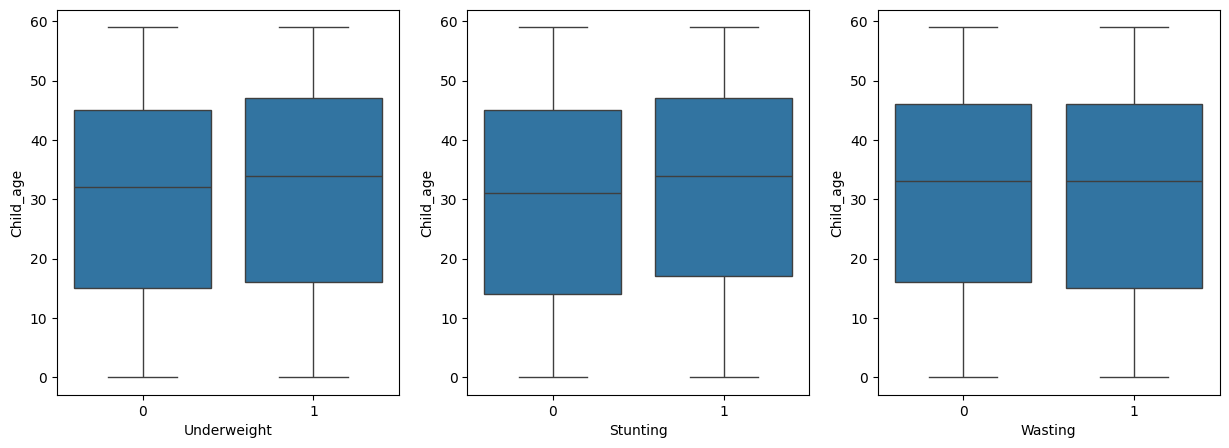

In [357]:
fig, axis = plt.subplots(1, 3, figsize=(15,5))
sns.boxplot(x='Underweight', y='Child_age', data=df3, ax=axis[0])
sns.boxplot(x='Stunting', y='Child_age', data=df3, ax=axis[1])
sns.boxplot(x='Wasting', y='Child_age', data=df3, ax = axis[2])
plt.show()

In [358]:
df3.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,Region,BMI,Children_under5,Total_children_ever_born,...,Ethnicity,Child_sex,Mother_age_current,Mother_age_at_first_birth,Father_education,Mother_working,Health_insurance,Underweight,Stunting,Wasting
0,41,basic,14.0,no,poorest,rural,koshi,NaN,1,1,...,hill janajati,female,29,17,complete primary,yes,no,1,1,1
2,42,basic,29.0,no,poorest,rural,koshi,NaN,2,2,...,hill chhetri,female,33,30,incomplete primary,no,no,1,1,1
3,17,basic,14.0,no,poorest,rural,koshi,22.0,1,1,...,hill chhetri,female,34,16,incomplete secondary,no,no,0,0,0
4,40,secondary,17.0,yes,poorer,rural,koshi,25.1,2,2,...,hill janajati,male,26,21,complete primary,yes,no,0,1,0
5,59,secondary,17.0,yes,poorer,rural,koshi,25.1,2,2,...,hill janajati,female,26,21,complete primary,yes,no,0,1,0


In [359]:
df3_encoded = pd.get_dummies(df3, columns=['Region', 'Religion', 'Ethnicity'], drop_first=True)
df3_encoded = df3_encoded.astype({col: int for col in df3_encoded.select_dtypes('bool').columns})
df3_encoded.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,BMI,Children_under5,Total_children_ever_born,Child_sex,...,Ethnicity_hill chhetri,Ethnicity_terai brahmin/chhetri,Ethnicity_other terai caste,Ethnicity_hill dalit,Ethnicity_terai dalit,Ethnicity_newar,Ethnicity_hill janajati,Ethnicity_terai janajati,Ethnicity_muslim,Ethnicity_other
0,41,basic,14.0,no,poorest,rural,NaN,1,1,female,...,0,0,0,0,0,0,1,0,0,0
2,42,basic,29.0,no,poorest,rural,NaN,2,2,female,...,1,0,0,0,0,0,0,0,0,0
3,17,basic,14.0,no,poorest,rural,22.0,1,1,female,...,1,0,0,0,0,0,0,0,0,0
4,40,secondary,17.0,yes,poorer,rural,25.1,2,2,male,...,0,0,0,0,0,0,1,0,0,0
5,59,secondary,17.0,yes,poorer,rural,25.1,2,2,female,...,0,0,0,0,0,0,1,0,0,0


### Variance Inflation Factor Check

In [360]:
# df3_vif = df3.drop(columns=['Underweight', 'Stunting', 'Wasting'])

X = add_constant(df3_encoded)

# Calculate VIF for each variable
vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print(vif)

/home/codespace/.python/current/lib/python3.12/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [ ]:
# Create a heatmap
correlation_matrix = df3_encoded.corr()

plt.figure(figsize=(15, 15))  # Set figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.1f')
plt.title("Correlation Matrix Heatmap")
plt.show()


In [ ]:
df3_encoded = df3_encoded.drop(columns=['Ethnicity_10', 'Age_first_sex'])

In [ ]:
# Add constant
X = add_constant(df3_encoded)

# Calculate VIF
vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print(vif)

In [ ]:
df3_encoded.to_csv("C:/Users/dbastola2022/OneDrive - Florida Atlantic University/Academics/Research/NDHS/Dataset/Children's Recode/Children Recode_final.csv", index=False)